In [16]:
import dask.dataframe as dd
from dask_ml.model_selection import train_test_split
from dask_ml.preprocessing import StandardScaler
from dask_ml.wrappers import ParallelPostFit

import time

from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

import matplotlib.pyplot as plt
import seaborn as sns
from tabulate import tabulate

In [15]:
%pip install dask
%pip install dask_ml
%pip install matplotlib
%pip install seaborn
%pip install tabulate


[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 15.8 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 15.0 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 17.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 13.0 MB/s eta 0:00:00 0:00:01

[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: python3 -

In [11]:
# Load data
iris_df = dd.read_csv("data/iris.csv")

# Encode labels (variety column as 'label')
label_encoder = LabelEncoder()
iris_df['label'] = label_encoder.fit_transform(iris_df['variety'])

# Define features and labels
features = iris_df[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']]
labels = iris_df['label']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(features, labels, test_size=0.1, random_state=42)

/usr/local/lib/python3.9/dist-packages/dask_ml/model_selection/_split.py:464: FutureWarning: The default value for 'shuffle' must be specified when splitting DataFrames. In the future DataFrames will automatically be shuffled within blocks prior to splitting. Specify 'shuffle=True' to adopt the future behavior now, or 'shuffle=False' to retain the previous behavior.
  warnings.warn(


In [12]:
pipelines = {
    "Decision Tree": Pipeline([
         ('scaler', StandardScaler()),
         ('clf', ParallelPostFit(DecisionTreeClassifier(max_depth=4)))
    ]),
    "Random Forest": Pipeline([
         ('scaler', StandardScaler()),
         ('clf', ParallelPostFit(RandomForestClassifier(n_estimators=100, max_depth=4, random_state=42)))
    ]),
    "Gradient Boosting": Pipeline([
         ('scaler', StandardScaler()),
         ('clf', ParallelPostFit(GradientBoostingClassifier(n_estimators=100, max_depth=4, random_state=42)))
    ])
}

In [18]:
results = {}

for name, pipeline in pipelines.items():
    start_time = time.time()
    pipeline.fit(X_train, y_train)
    fit_time = time.time() - start_time
    
    # Les prédictions sont renvoyées comme une collection Dask
    y_pred = pipeline.predict(X_test)
    
    # Conversion en array numpy pour l'évaluation
    y_test_np = y_test.compute()
    y_pred_np = y_pred.compute()
    
    acc = accuracy_score(y_test_np, y_pred_np)
    cm = confusion_matrix(y_test_np, y_pred_np)
    
    results[name] = {"accuracy": acc*100, "fit_time": fit_time, "confusion_matrix": cm}

/usr/local/lib/python3.9/dist-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(
/usr/local/lib/python3.9/dist-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/usr/local/lib/python3.9/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.9/dist-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(
/usr/local/lib/python3.9/dist-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_featur


--- Model Comparison ---
+-------------------+------------+----------------+
| Model             | Accuracy   | Fitting Time   |
+===================+============+================+
| Decision Tree     | 100.0000 % | 0.0601 seconds |
+-------------------+------------+----------------+
| Random Forest     | 100.0000 % | 0.1057 seconds |
+-------------------+------------+----------------+
| Gradient Boosting | 100.0000 % | 0.2088 seconds |
+-------------------+------------+----------------+


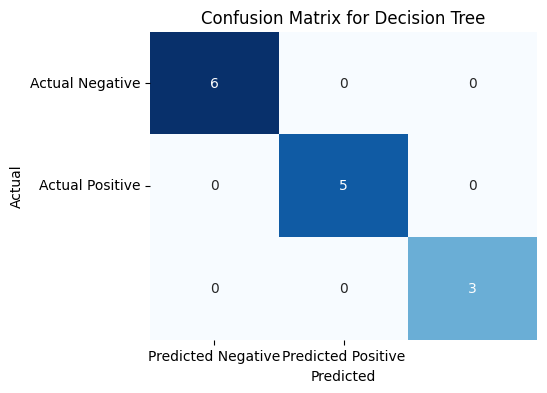

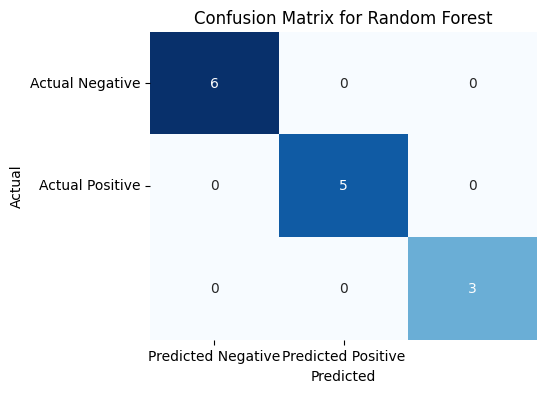

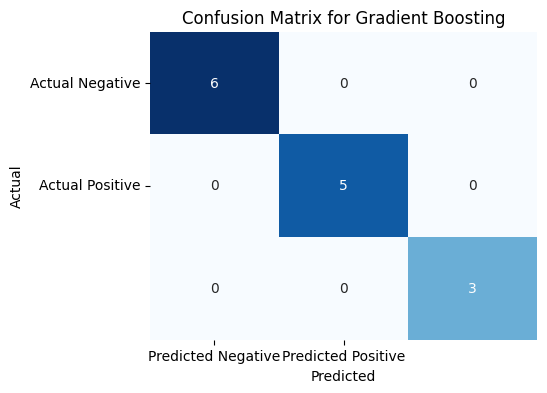

In [20]:
# Print tabular comparison of metrics
print("\n--- Model Comparison ---")
table = []
for name, res in results.items():
    table.append([
        name, 
        f"{res['accuracy']:.4f} %", 
        f"{res['fit_time']:.4f} seconds"
    ])

# Define headers for the table
headers = ["Model", "Accuracy", "Fitting Time"]

# Print table using tabulate for better format
print(tabulate(table, headers=headers, tablefmt="grid"))

# Plot confusion matrices as heatmaps
for name, res in results.items():
    cm = res["confusion_matrix"]
    
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, 
                xticklabels=["Predicted Negative", "Predicted Positive"], 
                yticklabels=["Actual Negative", "Actual Positive"])
    plt.title(f"Confusion Matrix for {name}")
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()